# Customer Churn Prediction

## Aim
The aim of this project is to build a machine learning model that can predict whether a customer is likely to churn. Churn means that a customer leaves the company or stops using the service. This is an important problem because retaining customers is usually cheaper than trying to acquire new ones.

In this notebook, I will go through the full machine learning workflow. I will first inspect and clean the data, then explore patterns in churn behaviour, prepare the data for modelling, train a couple of classification models, and finally compare their performance. The main goal is not just to build a model, but also to understand which factors seem to be linked to customer churn.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Importing and Inspecting the Dataset

The first step is to load the dataset and inspect its basic structure. I want to see how many rows and columns there are, what the variables look like, and whether any obvious data quality issues appear at the start. This gives a general sense of what needs to be cleaned before moving into analysis or modelling.

In [13]:
# Load the dataset
# Change the file name if needed depending on where your CSV is saved
churn_df = pd.read_csv("Telco-Customer-Churn.csv")

# Display the first few rows
print(churn_df.head())

# Check dimensions
print("Shape of dataset:", churn_df.shape)

# Check column information
print(churn_df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Data Cleaning

Before building any model, it is important to make sure the dataset is in a usable format. In this dataset, one issue that often appears is that the `TotalCharges` column is stored as text instead of numeric values. This usually happens because some rows contain blank spaces.

I will check for missing values, convert `TotalCharges` into a numeric variable, and remove any rows where this value is missing. I will also remove the customer ID column because it is only an identifier and should not help predict churn.

In [14]:
# Check missing values
print(churn_df.isnull().sum())

# Convert TotalCharges to numeric
# Any invalid values will become NaN
churn_df["TotalCharges"] = pd.to_numeric(churn_df["TotalCharges"], errors="coerce")

# Check how many missing values are now present in TotalCharges
print(churn_df["TotalCharges"].isnull().sum())

# Drop rows with missing TotalCharges
churn_df = churn_df.dropna(subset=["TotalCharges"])

# Remove customerID because it is not useful for prediction
if "customerID" in churn_df.columns:
    churn_df = churn_df.drop("customerID", axis=1)

# Convert target variable into binary format
churn_df["Churn"] = churn_df["Churn"].map({"Yes": 1, "No": 0})

# Preview cleaned dataset
print(churn_df.head())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
11
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL           

## Exploring the Target Variable

A useful early step is to look at the distribution of the target variable, which in this case is churn. This shows how many customers stayed and how many left. If the classes are imbalanced, accuracy on its own may not be enough to judge model performance, so it is worth checking this before training any model.

0    5163
1    1869
Name: Churn, dtype: int64
0    0.734215
1    0.265785
Name: Churn, dtype: float64


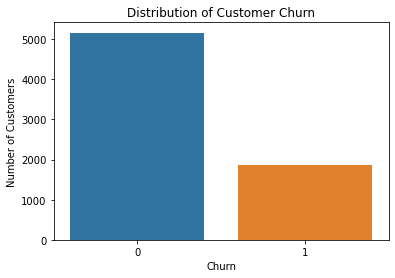

In [15]:
# Count how many customers churned and how many stayed
print(churn_df["Churn"].value_counts())
print(churn_df["Churn"].value_counts(normalize=True))

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=churn_df)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Exploratory Data Analysis

Next, I want to look at a few variables that are likely to have a relationship with churn. In particular, contract type, internet service, monthly charges, and tenure are all likely to matter.

These plots help to show whether certain customer groups are more likely to leave than others. This is useful both from a modelling point of view and from a business point of view, because it helps identify possible risk factors linked to churn.

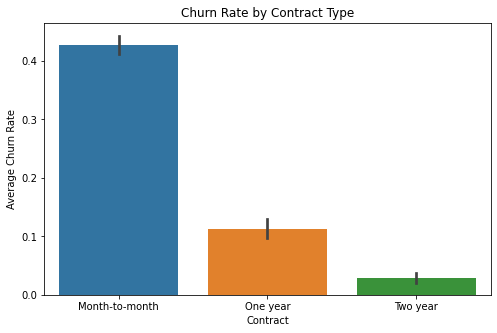

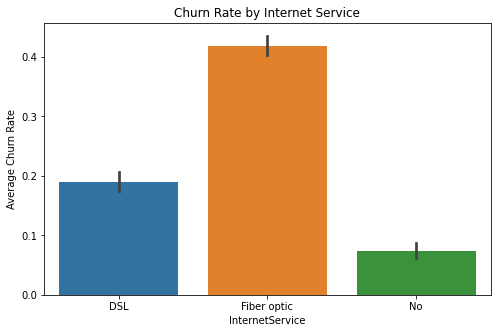

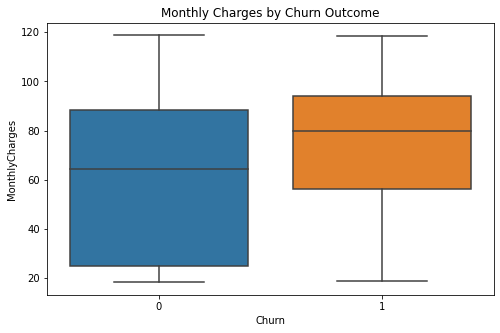

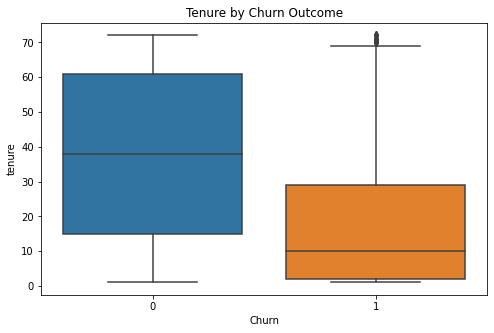

In [18]:
# Churn rate by contract type
plt.figure(figsize=(8, 5))
sns.barplot(x="Contract", y="Churn", data=churn_df)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Average Churn Rate")
plt.show()

# Churn rate by internet service
plt.figure(figsize=(8, 5))
sns.barplot(x="InternetService", y="Churn", data=churn_df)
plt.title("Churn Rate by Internet Service")
plt.ylabel("Average Churn Rate")
plt.show()

# Monthly charges by churn outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=churn_df)
plt.title("Monthly Charges by Churn Outcome")
plt.show()

# Tenure by churn outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=churn_df)
plt.title("Tenure by Churn Outcome")
plt.show()

## Early Findings from the EDA

From the initial plots, there are a few patterns that stand out. Customers on month-to-month contracts seem much more likely to churn than customers on longer-term contracts. This makes sense because customers on shorter contracts have less commitment and can leave more easily.

It also looks like customers who churn tend to have higher monthly charges on average. Another noticeable pattern is that customers with shorter tenure appear more likely to leave, which could suggest that churn risk is especially high in the earlier stages of the customer relationship.

These observations are only descriptive at this stage, but they give a useful starting point before moving into machine learning.

## Preparing the Data for Machine Learning

The next step is to separate the features from the target variable and split the data into training and testing sets. The training set will be used to fit the models, while the test set will be used to evaluate how well the models perform on unseen data.

I will also identify which columns are numeric and which are categorical, because they need different preprocessing steps. Numeric variables will be scaled, while categorical variables will be converted into numeric format using one-hot encoding.

In [19]:
# Separate features and target
X = churn_df.drop("Churn", axis=1)
y = churn_df["Churn"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [22]:
# Preprocessing for numeric columns
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Model Selection

For this project, I decided to use two different classification models: Logistic Regression and Random Forest. Logistic Regression is a good baseline model because it is simple, fast, and easy to interpret. Random Forest is more flexible and can capture more complex relationships in the data.

Using both models makes it easier to compare a straightforward linear approach with a more advanced tree-based method.

In [24]:
# Logistic Regression pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Train both models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

## Model Evaluation

To evaluate the models properly, I will use several metrics rather than just accuracy. Accuracy can sometimes be misleading, especially if one class is much more common than the other.

Precision shows how many predicted churn cases were actually correct, while recall shows how many of the true churn cases were successfully identified. The F1-score gives a balance between precision and recall, and ROC-AUC measures how well the model separates churners from non-churners overall.

Since the main business goal is often to identify customers who are at risk of leaving, recall can be especially important in a churn prediction problem.

In [29]:
# Predictions from Logistic Regression
log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:, 1]

# Predictions from Random Forest
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Function to print model metrics

def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\nResults for {model_name}")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("F1-score:", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_prob), 3))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# Evaluate both models
evaluate_model(y_test, log_preds, log_probs, "Logistic Regression")
evaluate_model(y_test, rf_preds, rf_probs, "Random Forest")


Results for Logistic Regression
Accuracy: 0.805
Precision: 0.65
Recall: 0.575
F1-score: 0.61
ROC-AUC: 0.836

Confusion Matrix:
[[917 116]
 [159 215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Results for Random Forest
Accuracy: 0.79
Precision: 0.634
Recall: 0.492
F1-score: 0.554
ROC-AUC: 0.814

Confusion Matrix:
[[927 106]
 [190 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Interpreting the Results

Once both models are evaluated, I can compare which one performs better across the main metrics. In a project like this, the best model is not always the one with the highest accuracy. It is often more useful to focus on recall or F1-score if the aim is to identify customers who may leave.

If Logistic Regression performs similarly to Random Forest, it may still be the better option because it is easier to explain. On the other hand, if Random Forest performs clearly better, it may be worth choosing that model despite being less interpretable.

Top Logistic Regression features:
                             Feature  Coefficient
1                        num__tenure    -1.349816
36      cat__Contract_Month-to-month     0.719375
16  cat__InternetService_Fiber optic     0.703220
38            cat__Contract_Two year    -0.670445
3                  num__TotalCharges     0.641335
2                num__MonthlyCharges    -0.559429
15          cat__InternetService_DSL    -0.515411
32              cat__StreamingTV_Yes     0.301363
35          cat__StreamingMovies_Yes     0.287426
18            cat__OnlineSecurity_No     0.269941
Top Random Forest features:
                                Feature  Importance
3                     num__TotalCharges    0.158200
1                           num__tenure    0.142352
2                   num__MonthlyCharges    0.136054
36         cat__Contract_Month-to-month    0.053717
18               cat__OnlineSecurity_No    0.031239
43  cat__PaymentMethod_Electronic check    0.029722
16     cat__InternetServ

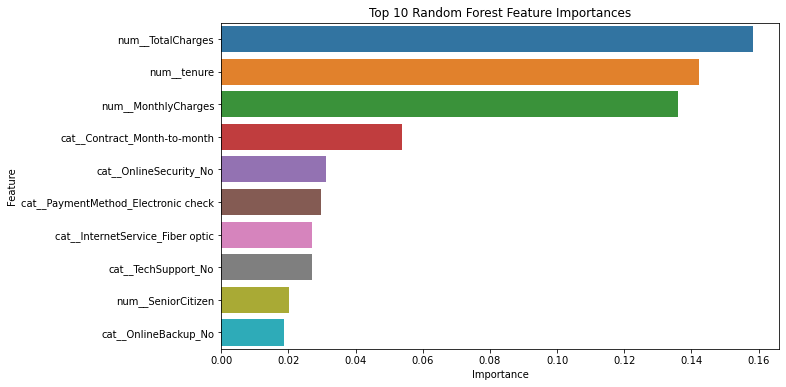

In [34]:
# Get transformed feature names
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()

# Logistic Regression coefficients
log_coefficients = log_model.named_steps["classifier"].coef_[0]

log_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_coefficients
})

log_coef_df["AbsoluteCoefficient"] = log_coef_df["Coefficient"].abs()
log_coef_df = log_coef_df.sort_values(by="AbsoluteCoefficient", ascending=False)

print("Top Logistic Regression features:")
print(log_coef_df[["Feature", "Coefficient"]].head(10))

# Random Forest feature importance
rf_importance = rf_model.named_steps["classifier"].feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

print("Top Random Forest features:")
print(rf_importance_df.head(10))

# Plot top feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df.head(10), x="Importance", y="Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

## Conclusion

Overall, this project shows a full machine learning workflow for a customer churn problem. After cleaning the data and exploring some of the main patterns, I built two classification models and compared their performance using a range of evaluation metrics.

The analysis suggests that variables such as contract type, tenure, and monthly charges are likely to play an important role in explaining churn behaviour. From a business point of view, this could help a company identify customers who are at greater risk of leaving and target them with retention strategies.

A natural next step would be to tune the models further, test additional algorithms, or adjust the classification threshold depending on whether the business values recall, precision, or a balance of both.